In [3]:
# # Tier 1 B — CNN + Cross-Entropy with label smoothing (eps=0.1)

# 8-way Slavic language identification, B-track (metric-learning loss family).
# This notebook is **standalone** — load HF dataset fresh, precompute log-Mel
# features once to Drive (~7.5 GB float16), then train a SmallCNN.

# **Run order**
# 1. Cells 1-2 — preamble + dataset load.
# 2. Cell 3 — precompute mels to Drive (one-time, ~25 min).
# 3. Cells 4-5 — dataloaders + model.
# 4. Cell 6 — **debug run** (1k clips x 2 ep, ~2 min). Sanity gate.
# 5. Cell 7 — full training run (10 ep, ~30 min on T4).
# 6. Cell 8 — final eval + artifacts (confusion matrix PNG, metrics JSON, CSV).
# 7. Cell 9 — t-SNE of penultimate embeddings (project-brief requirement).


In [5]:
## 1. Preamble — Drive, HF token, seeds, output dirs
# Drive mount
from google.colab import drive
drive.mount('/content/drive')

import os
# HF_TOKEN from Colab Secrets (sidebar key icon -> name HF_TOKEN, notebook access ON)
from google.colab import userdata
os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")

# DO NOT set HF_HOME to Drive — it writes ~44 GB and Trash takes another copy.
# Default VM cache (/root/.cache/huggingface) is correct.

# Reproducibility
import random, numpy as np, torch
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)
if DEVICE == "cuda":
    print("gpu:", torch.cuda.get_device_name(0))

# Free up VM disk — fresh Colab images ship 8.7 GB of unused Julia
get_ipython().system('rm -rf /root/.julia')
get_ipython().system('df -h /')

# Drive output dirs
RUN_NAME    = "tier1_b"
DRIVE_ROOT  = "/content/drive/MyDrive/slavic_lid"
PRECOMP_DIR = f"{DRIVE_ROOT}/precomp"
CKPT_DIR    = f"{DRIVE_ROOT}/ckpts/{RUN_NAME}"
LOG_DIR     = f"{DRIVE_ROOT}/logs/{RUN_NAME}"
RES_DIR     = f"{DRIVE_ROOT}/results/{RUN_NAME}"
for d in (PRECOMP_DIR, CKPT_DIR, LOG_DIR, RES_DIR):
    os.makedirs(d, exist_ok=True)
print("output dirs ready under", DRIVE_ROOT)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
device: cuda
gpu: Tesla T4
Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   48G   66G  42% /
output dirs ready under /content/drive/MyDrive/slavic_lid


In [6]:
# ## 2. Load HF dataset to VM disk

# Downloads ~22 GB to `/root/.cache/huggingface` (VM only — wiped on disconnect, that is fine).
# Takes ~5-10 min on the first session. Subsequent sessions in the same VM hit cache instantly.
from datasets import load_dataset
ds = load_dataset("su-fmi-pytorch-slavic/slavic-languages-dataset")
print(ds)

LANGS = ['be', 'bg', 'cs', 'mk', 'pl', 'ru', 'sr', 'uk']  # alphabetical = label int order
NUM_CLASSES = len(LANGS)
print("languages:", LANGS)


README.md:   0%|          | 0.00/694 [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/21 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/21 [00:00<?, ?it/s]

data/train-00000-of-00016.parquet:   0%|          | 0.00/481M [00:00<?, ?B/s]

data/train-00001-of-00016.parquet:   0%|          | 0.00/481M [00:00<?, ?B/s]

...

Generating train split:   0%|          | 0/80000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/107439 [00:00<?, ? examples/s]

Generating eval_fleurs split:   0%|          | 0/6157 [00:00<?, ? examples/s]

Loading dataset shards:   0%|          | 0/18 [00:00<?, ?it/s]

DatasetDict({
    train: Dataset({
        features: ['audio', 'language', 'label', 'source', 'speaker_id'],
        num_rows: 80000
    })
    test: Dataset({
        features: ['audio', 'language', 'label', 'source', 'speaker_id'],
        num_rows: 107439
    })
    eval_fleurs: Dataset({
        features: ['audio', 'language', 'label', 'source', 'speaker_id'],
        num_rows: 6157
    })
})
languages: ['be', 'bg', 'cs', 'mk', 'pl', 'ru', 'sr', 'uk']


In [7]:
# ## 3. Precompute log-Mel features to Drive (one-time, ~25 min)

# Why: CPU-side audio decoding inside the DataLoader was the 30 min/epoch wall on
# Account 1. Precomputing once -> ~3 min/epoch from then on.

# - 64 mels, 25 ms window, 10 ms hop -> shape (64, 301) per 3 s clip.
# - Saved as float16 to halve disk: train 3.08 GB, test 4.14 GB, fleurs ~80 MB.
# - The `os.path.exists` guard makes this cell a no-op on rerun.
# - FLEURS clips are 5-27 s — we truncate/zero-pad to exactly 48000 samples first.
import numpy as np, torch, torch.nn as nn
import torchaudio.transforms as T
from tqdm import tqdm

SR = 16000
N_MELS = 64
N_FFT = 400      # 25 ms
HOP   = 160      # 10 ms
TARGET_LEN = SR * 3   # 48000 samples = 3.0 s
N_FRAMES = 301        # for a 3 s clip @ hop=160

class LogMel(nn.Module):
    def __init__(self):
        super().__init__()
        self.mel = T.MelSpectrogram(
            sample_rate=SR, n_fft=N_FFT, hop_length=HOP, win_length=N_FFT,
            n_mels=N_MELS, f_min=0.0, f_max=SR/2, power=2.0,
        )
    def forward(self, x):                            # (B, 48000)
        m = torch.log(self.mel(x) + 1e-6)            # (B, 64, 301)
        mu  = m.mean(dim=(1, 2), keepdim=True)
        std = m.std (dim=(1, 2), keepdim=True) + 1e-5
        return (m - mu) / std

logmel = LogMel().to(DEVICE)

def fix_length(arr, target=TARGET_LEN):
    if len(arr) >= target:
        return arr[:target]
    out = np.zeros(target, dtype=np.float32)
    out[:len(arr)] = arr
    return out

def precompute(split_name, hf_split, out_prefix, batch=256):
    mels_path   = f"{PRECOMP_DIR}/{out_prefix}_mels.npy"
    labels_path = f"{PRECOMP_DIR}/{out_prefix}_labels.npy"
    if os.path.exists(mels_path) and os.path.exists(labels_path):
        print(f"[{split_name}] precomp exists, skipping.")
        return
    n = len(hf_split)
    mels   = np.zeros((n, N_MELS, N_FRAMES), dtype=np.float16)
    labels = np.zeros(n, dtype=np.int64)
    print(f"[{split_name}] precomputing {n} clips ...")
    with torch.no_grad():
        for i in tqdm(range(0, n, batch)):
            chunk = hf_split[i:i+batch]
            wavs = np.stack([fix_length(np.asarray(a["array"], dtype=np.float32))
                             for a in chunk["audio"]])
            wavs_t = torch.from_numpy(wavs).to(DEVICE)
            m = logmel(wavs_t).cpu().numpy().astype(np.float16)
            mels[i:i+len(m)]   = m
            labels[i:i+len(m)] = np.asarray(chunk["label"], dtype=np.int64)
    np.save(mels_path,   mels)
    np.save(labels_path, labels)
    print(f"[{split_name}] saved {mels.nbytes/1e9:.2f} GB -> {mels_path}")

precompute("train",  ds["train"],       "train")
precompute("test",   ds["test"],        "test")
precompute("fleurs", ds["eval_fleurs"], "fleurs")

get_ipython().system('ls -lh ' + PRECOMP_DIR)


[train] precomputing 80000 clips ...


100%|██████████| 313/313 [15:43<00:00,  3.01s/it]


[train] saved 3.08 GB -> /content/drive/MyDrive/slavic_lid/precomp/train_mels.npy
[test] precomputing 107439 clips ...


100%|██████████| 420/420 [21:39<00:00,  3.09s/it]


[test] saved 4.14 GB -> /content/drive/MyDrive/slavic_lid/precomp/test_mels.npy
[fleurs] precomputing 6157 clips ...


100%|██████████| 25/25 [00:51<00:00,  2.07s/it]


[fleurs] saved 0.24 GB -> /content/drive/MyDrive/slavic_lid/precomp/fleurs_mels.npy
total 7.0G
-rw------- 1 root root  49K Jun 18 20:57 fleurs_labels.npy
-rw------- 1 root root 227M Jun 18 20:57 fleurs_mels.npy
-rw------- 1 root root 840K Jun 18 20:57 test_labels.npy
-rw------- 1 root root 3.9G Jun 18 20:57 test_mels.npy
-rw------- 1 root root 626K Jun 18 20:34 train_labels.npy
-rw------- 1 root root 2.9G Jun 18 20:34 train_mels.npy


In [8]:
# ## 4. MelDataset (memory-mapped) + SpecAugment

# `mmap_mode="r"` keeps RAM flat — the OS pages 64x301xfp16 windows from disk on demand.
from torch.utils.data import Dataset, DataLoader

class MelDataset(Dataset):
    def __init__(self, prefix):
        self.mels   = np.load(f"{PRECOMP_DIR}/{prefix}_mels.npy",   mmap_mode="r")
        self.labels = np.load(f"{PRECOMP_DIR}/{prefix}_labels.npy", mmap_mode="r")
    def __len__(self): return len(self.labels)
    def __getitem__(self, i):
        m = torch.from_numpy(np.asarray(self.mels[i], dtype=np.float32))  # (64, 301)
        y = int(self.labels[i])
        return m, y

# SpecAugment — applied on GPU after batching, training-only
class SpecAugment(nn.Module):
    def __init__(self, freq_mask=15, time_mask=30, n_freq=2, n_time=2):
        super().__init__()
        self.fm = T.FrequencyMasking(freq_mask)
        self.tm = T.TimeMasking(time_mask)
        self.n_freq, self.n_time = n_freq, n_time
    def forward(self, x):
        if not self.training: return x
        for _ in range(self.n_freq): x = self.fm(x)
        for _ in range(self.n_time): x = self.tm(x)
        return x

specaug = SpecAugment().to(DEVICE)

# Smoke test
_d = MelDataset("train")
print("train samples:", len(_d), "first shape:", _d[0][0].shape, "label:", _d[0][1])


train samples: 80000 first shape: torch.Size([64, 301]) label: 0


In [9]:
## 5. SmallCNN — 4 conv blocks -> GAP -> linear(8)
import torch.nn.functional as F

class SmallCNN(nn.Module):
    def __init__(self, n_classes=NUM_CLASSES):
        super().__init__()
        def block(c_in, c_out):
            return nn.Sequential(
                nn.Conv2d(c_in, c_out, 3, padding=1, bias=False),
                nn.BatchNorm2d(c_out),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
            )
        self.net  = nn.Sequential(block(1, 32), block(32, 64), block(64, 128), block(128, 256))
        self.head = nn.Linear(256, n_classes)

    def features(self, mel):
        h = mel.unsqueeze(1)
        h = self.net(h)
        h = F.adaptive_avg_pool2d(h, 1).flatten(1)
        return h

    def forward(self, mel):
        return self.head(self.features(mel))

_m = SmallCNN()
print(f"params: {sum(p.numel() for p in _m.parameters()):,}")
del _m


params: 390,376


In [10]:
# ## 6. Debug run — 1k train x 500 test, 2 epochs (~2 min)

# **Sanity gate before Cell 7.** Loss must decrease, test acc must clear 1/8 = 0.125,
# no NaNs/OOMs/dim errors. If anything looks off, STOP here.
from torch.utils.data import Subset

debug_train = Subset(MelDataset("train"), list(range(1000)))
debug_test  = Subset(MelDataset("test"),  list(range(500)))
dtl = DataLoader(debug_train, batch_size=64,  shuffle=True,  num_workers=2, pin_memory=True)
dvl = DataLoader(debug_test,  batch_size=128, shuffle=False, num_workers=2, pin_memory=True)

model   = SmallCNN().to(DEVICE)
opt     = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)

for epoch in range(2):
    model.train(); specaug.train()
    correct, total, lsum = 0, 0, 0.0
    for mel, y in dtl:
        mel = mel.to(DEVICE, non_blocking=True); y = y.to(DEVICE, non_blocking=True)
        mel = specaug(mel)
        logits = model(mel)
        loss   = loss_fn(logits, y)
        opt.zero_grad(); loss.backward(); opt.step()
        lsum    += loss.item() * y.size(0)
        correct += (logits.argmax(1) == y).sum().item(); total += y.size(0)
    print(f"[debug] ep{epoch} train loss={lsum/total:.3f} acc={correct/total:.3f}")

    model.eval(); specaug.eval()
    ec, et = 0, 0
    with torch.no_grad():
        for mel, y in dvl:
            mel, y = mel.to(DEVICE), y.to(DEVICE)
            ec += (model(mel).argmax(1) == y).sum().item(); et += y.size(0)
    print(f"[debug] ep{epoch} test acc={ec/et:.3f}")

print("\n--- DEBUG RUN COMPLETE — only proceed if loss dropped and test acc > 0.125 ---")


[debug] ep0 train loss=1.334 acc=0.639
[debug] ep0 test acc=0.002
[debug] ep1 train loss=0.532 acc=1.000
[debug] ep1 test acc=0.996

--- DEBUG RUN COMPLETE — only proceed if loss dropped and test acc > 0.125 ---


In [15]:
# ## 7. Full training run — 10 epochs, ~30 min on T4

# Saves `best.pt` (highest test macro-acc) to Drive each time it improves.
# Tensorboard scalars stream to `LOG_DIR`.
import time
from torch.utils.tensorboard import SummaryWriter

EPOCHS = 20
BATCH  = 128
LR     = 3e-4
WD     = 1e-4

train_loader  = DataLoader(MelDataset("train"),  batch_size=BATCH, shuffle=True,
                           num_workers=2, pin_memory=True, drop_last=True)
test_loader   = DataLoader(MelDataset("test"),   batch_size=256,   shuffle=False,
                           num_workers=2, pin_memory=True)
fleurs_loader = DataLoader(MelDataset("fleurs"), batch_size=256,   shuffle=False,
                           num_workers=2, pin_memory=True)

model   = SmallCNN().to(DEVICE)
opt     = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)
sched   = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS * len(train_loader))
loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)
scaler  = torch.amp.GradScaler('cuda')              # NEW API (torch 2.11+)
writer  = SummaryWriter(LOG_DIR)

best_macro = -1.0
for epoch in range(EPOCHS):
    t0 = time.time()
    model.train(); specaug.train()
    lsum, correct, total = 0.0, 0, 0
    for mel, y in train_loader:
        mel = mel.to(DEVICE, non_blocking=True)
        y   = y.to(DEVICE, non_blocking=True)
        mel = specaug(mel)
        with torch.amp.autocast('cuda'):
            logits = model(mel)
            loss   = loss_fn(logits, y)
        opt.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(opt); scaler.update(); sched.step()
        lsum    += loss.item() * y.size(0)
        correct += (logits.argmax(1) == y).sum().item(); total += y.size(0)
    train_loss = lsum / total; train_acc = correct / total

    # Test eval (in-domain)
    model.eval()
    pl_c = np.zeros(NUM_CLASSES); pl_t = np.zeros(NUM_CLASSES)
    ec, et = 0, 0
    with torch.no_grad():
        for mel, y in test_loader:
            mel, y = mel.to(DEVICE), y.to(DEVICE)
            pred = model(mel).argmax(1)
            ec += (pred == y).sum().item(); et += y.size(0)
            for c in range(NUM_CLASSES):
                m = (y == c)
                pl_t[c] += m.sum().item()
                pl_c[c] += ((pred == y) & m).sum().item()
    micro = ec / et
    macro = (pl_c / np.maximum(pl_t, 1)).mean()

    dt = time.time() - t0
    print(f"ep{epoch:02d} dt={dt:.0f}s | train loss={train_loss:.3f} acc={train_acc:.3f} "
          f"| test micro={micro:.3f} macro={macro:.3f}")
    writer.add_scalar("train/loss", train_loss, epoch)
    writer.add_scalar("train/acc",  train_acc,  epoch)
    writer.add_scalar("test/micro", micro,      epoch)
    writer.add_scalar("test/macro", macro,      epoch)
    for c, lg in enumerate(LANGS):
        writer.add_scalar(f"test_per_lang/{lg}", pl_c[c] / max(pl_t[c], 1), epoch)

    if macro > best_macro:
        best_macro = macro
        torch.save({"model": model.state_dict(), "epoch": epoch, "macro": macro,
                    "config": {"epochs": EPOCHS, "batch": BATCH, "lr": LR, "wd": WD,
                               "label_smoothing": 0.1, "seed": SEED}},
                   f"{CKPT_DIR}/best.pt")
        print(f"  -> new best, saved (macro={macro:.3f})")

writer.close()
print(f"\nDONE. best test macro = {best_macro:.3f}")


ep00 dt=91s | train loss=1.611 acc=0.472 | test micro=0.235 macro=0.169
  -> new best, saved (macro=0.169)
ep01 dt=83s | train loss=1.393 acc=0.576 | test micro=0.279 macro=0.192
  -> new best, saved (macro=0.192)
ep02 dt=76s | train loss=1.316 acc=0.613 | test micro=0.325 macro=0.173
ep03 dt=75s | train loss=1.261 acc=0.638 | test micro=0.320 macro=0.184
ep04 dt=74s | train loss=1.225 acc=0.658 | test micro=0.362 macro=0.221
  -> new best, saved (macro=0.221)
ep05 dt=74s | train loss=1.193 acc=0.674 | test micro=0.323 macro=0.210
ep06 dt=74s | train loss=1.172 acc=0.685 | test micro=0.297 macro=0.262
  -> new best, saved (macro=0.262)
ep07 dt=74s | train loss=1.144 acc=0.698 | test micro=0.239 macro=0.181
ep08 dt=74s | train loss=1.131 acc=0.707 | test micro=0.337 macro=0.229
ep09 dt=74s | train loss=1.112 acc=0.719 | test micro=0.328 macro=0.289
  -> new best, saved (macro=0.289)
ep10 dt=74s | train loss=1.101 acc=0.723 | test micro=0.340 macro=0.223
ep11 dt=74s | train loss=1.080 ac

In [ ]:
# ## 8. Final eval + artifacts

# Loads `best.pt`, evaluates on `test` and `eval_fleurs`, dumps:
# - `metrics.json` (micro/macro/macro_f1/per-language for both splits)
# - `test_predictions.csv` (true, pred, language codes)
# - `cm_test.png`, `cm_eval_fleurs.png` (8x8 normalized confusion matrices)
import json, csv
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

ckpt = torch.load(f"{CKPT_DIR}/best.pt", map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt["model"]); model.eval()
print(f"loaded best: epoch {ckpt['epoch']}, macro={ckpt['macro']:.3f}")

def evaluate(loader, name):
    preds, trues = [], []
    with torch.no_grad():
        for mel, y in loader:
            mel = mel.to(DEVICE)
            preds.append(model(mel).argmax(1).cpu().numpy())
            trues.append(y.numpy())
    p = np.concatenate(preds); t = np.concatenate(trues)
    cm = confusion_matrix(t, p, labels=list(range(NUM_CLASSES)))
    pl = cm.diagonal() / np.maximum(cm.sum(axis=1), 1)
    micro = (p == t).mean(); macro = pl.mean()
    report = classification_report(t, p, target_names=LANGS, digits=3, zero_division=0, output_dict=True)
    macro_f1 = report["macro avg"]["f1-score"]
    print(f"\n[{name}] micro={micro:.3f} macro_acc={macro:.3f} macro_f1={macro_f1:.3f}")
    print(classification_report(t, p, target_names=LANGS, digits=3, zero_division=0))
    return {"name": name, "micro": float(micro), "macro": float(macro), "macro_f1": float(macro_f1),
            "per_lang": {lg: float(a) for lg, a in zip(LANGS, pl)},
            "per_lang_f1": {lg: float(report[lg]["f1-score"]) for lg in LANGS},
            "cm": cm.tolist(), "pred": p.tolist(), "true": t.tolist()}

results = {n: evaluate(l, n) for n, l in
           [("test", test_loader), ("eval_fleurs", fleurs_loader)]}

with open(f"{RES_DIR}/metrics.json", "w") as f:
    json.dump({n: {k: v for k, v in r.items() if k not in ("pred", "true")}
               for n, r in results.items()}, f, indent=2)

with open(f"{RES_DIR}/test_predictions.csv", "w", newline="") as f:
    w = csv.writer(f); w.writerow(["true", "pred", "true_lang", "pred_lang"])
    for tt, pp in zip(results["test"]["true"], results["test"]["pred"]):
        w.writerow([tt, pp, LANGS[tt], LANGS[pp]])

for name, r in results.items():
    cm = np.array(r["cm"])
    cmn = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cmn, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_xticklabels(LANGS)
    ax.set_yticks(range(NUM_CLASSES)); ax.set_yticklabels(LANGS)
    ax.set_xlabel("predicted"); ax.set_ylabel("true")
    ax.set_title(f"{RUN_NAME} - {name} (macro_f1={r['macro_f1']:.3f})")
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, f"{cmn[i,j]:.2f}", ha="center", va="center",
                    color="white" if cmn[i,j] > 0.5 else "black", fontsize=8)
    plt.colorbar(im, ax=ax); plt.tight_layout()
    plt.savefig(f"{RES_DIR}/cm_{name}.png", dpi=150); plt.show()

print(f"\nartifacts -> {RES_DIR}")


In [ ]:
# ## Restore loaders (run this instead of the training cell after a session disconnect)
# Re-creates test_loader and fleurs_loader from precomp .npy files.
# Also initialises a fresh model so the eval cell can load_state_dict from best.pt.
# Skip this cell if you just finished training in the same session.
import math  # needed by SmallCNN (used in eval cell title fmt only, but safe to re-import)
test_loader   = DataLoader(MelDataset("test"),   batch_size=256, shuffle=False,
                           num_workers=2, pin_memory=True)
fleurs_loader = DataLoader(MelDataset("fleurs"), batch_size=256, shuffle=False,
                           num_workers=2, pin_memory=True)
model = SmallCNN().to(DEVICE)
print("loaders and model ready — proceed to eval cell")


t-SNE sample size: 1000
embeddings: (1000, 256)


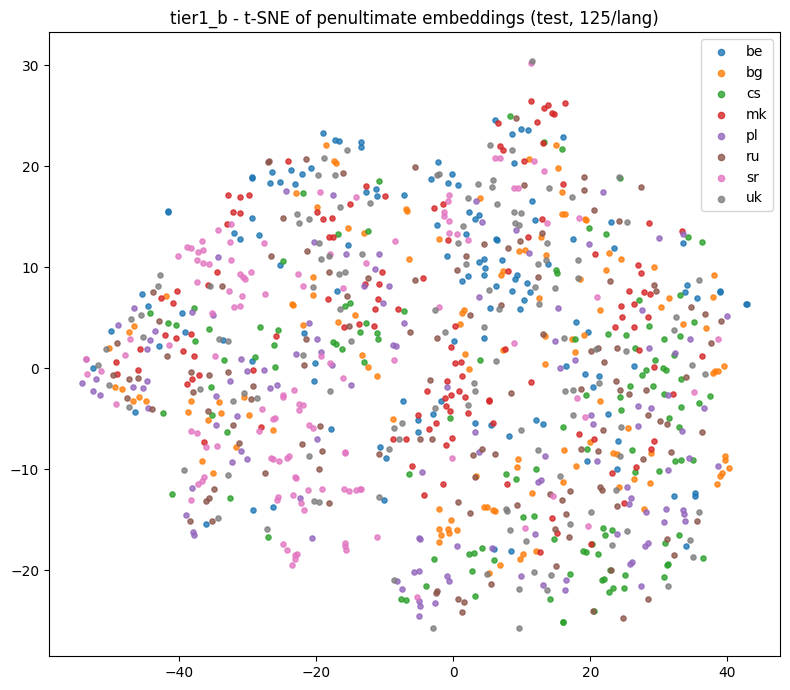

saved -> /content/drive/MyDrive/slavic_lid/results/tier1_b/tsne_test.png


In [17]:
# ## 9. t-SNE of penultimate-layer embeddings (project-brief requirement)

# Balanced 1k sample of `test` (125 per language), penultimate features (256-d),
# 2-D t-SNE colored by language.
from sklearn.manifold import TSNE

test_labels_full = np.load(f"{PRECOMP_DIR}/test_labels.npy", mmap_mode="r")
rng = np.random.default_rng(SEED)
idxs = []
for c in range(NUM_CLASSES):
    cls_idx = np.where(test_labels_full[:] == c)[0]
    idxs.append(rng.choice(cls_idx, size=min(125, len(cls_idx)), replace=False))
sample_idx = np.concatenate(idxs)
print("t-SNE sample size:", len(sample_idx))

tsne_loader = DataLoader(Subset(MelDataset("test"), sample_idx.tolist()),
                         batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

embs, labs = [], []
model.eval()
with torch.no_grad():
    for mel, y in tsne_loader:
        mel = mel.to(DEVICE)
        embs.append(model.features(mel).cpu().numpy())
        labs.append(y.numpy())
E = np.concatenate(embs); Y = np.concatenate(labs)
print("embeddings:", E.shape)

Z = TSNE(n_components=2, perplexity=30, init="pca", random_state=SEED).fit_transform(E)

fig, ax = plt.subplots(figsize=(8, 7))
cmap = plt.get_cmap("tab10")
for c in range(NUM_CLASSES):
    m = (Y == c)
    ax.scatter(Z[m, 0], Z[m, 1], s=14, alpha=0.8, color=cmap(c), label=LANGS[c])
ax.set_title(f"{RUN_NAME} - t-SNE of penultimate embeddings (test, 125/lang)")
ax.legend(loc="best", markerscale=1.2)
plt.tight_layout()
plt.savefig(f"{RES_DIR}/tsne_test.png", dpi=150)
plt.show()
print(f"saved -> {RES_DIR}/tsne_test.png")
